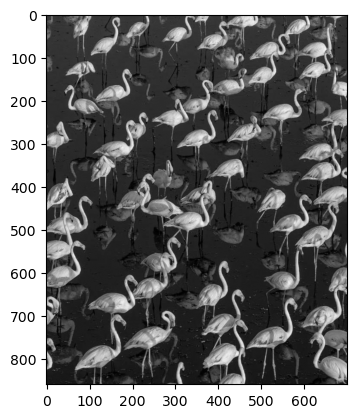

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
import matplotlib.image as mpimg
%matplotlib inline

im = mpimg.imread("bird.jpg")
gray = np.dot(im, [0.299, 0.587, 0.144])  
plt.imshow(gray, cmap = plt.get_cmap('gray'))

height, width = gray.shape
eight = 80
tiles = {}

# Calculate how many tiles fit in the height and width
for y in range(0, height, eight):
    for x in range(0, width, eight):
        # Extract the 80x80 block using slicing
        tile = gray[y:y+eight, x:x+eight]
        
        # Check if the tile is a full 80x80 (handles edge cases)
        if tile.shape == (eight, eight):
            tiles[(x//eight, y//eight)] = tile
        else:
            # Optional: Handle partial tiles at the edges
            # You could pad them with zeros or just skip them
            pass

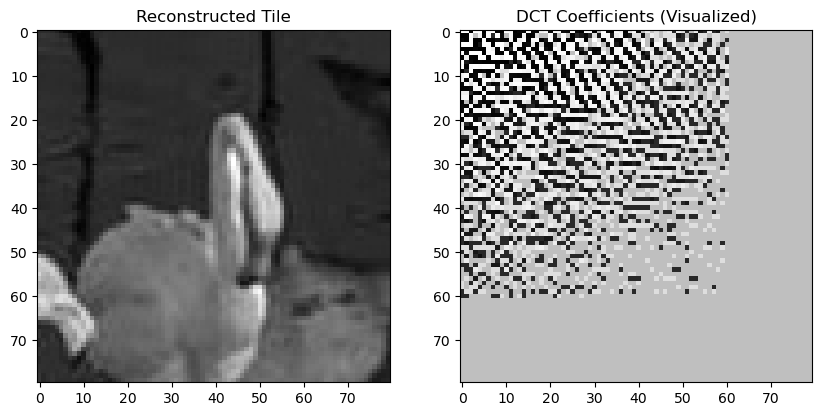

In [12]:
from scipy.fftpack import dct, idct
import numpy as np
import matplotlib.pyplot as plt

dct_tiles = {}
new_tiles = {}

def visualize_dct(d):
    # Ensure we don't divide by zero if the tile is blank
    d_max = d.max()
    if d_max == 0:
        return np.zeros(d.shape)
        
    d_shifted = d + abs(d.min())
    # Recalculate max after shift for histogram range
    d_shifted_max = d_shifted.max()
    
    h = np.histogram(d_shifted, bins=1000, range=(0, d_shifted_max))
    c = 255.0 * np.cumsum(h[0]) / sum(h[0])
    
    new_img = np.zeros(d.shape)
    for index, value in np.ndenumerate(d_shifted): 
        # Using min(..., 999) prevents index out of bounds.
        bin_idx = int(999.0 * value / d_shifted_max)
        new_img[index] = c[min(bin_idx, 999)]    
    return new_img  

for key, tile in tiles.items():
    # Use norm='ortho' so idct(dct(tile)) == tile without manual division
    # We apply dct to rows (axis=0) then columns (axis=1) for a 2D DCT
    dct_2d = dct(dct(tile, axis=0, norm='ortho'), axis=1, norm='ortho')
    
    # Low-pass filter: Zero out high-frequency components
    # (The bottom-right of the DCT matrix represents high frequencies)
    for y in range(eight):
        for x in range(eight):
            if x > 60 or y > 60: 
                dct_2d[y][x] = 0
    
    # Store the filtered tile and the visualization
    new_tiles[key] = idct(idct(dct_2d, axis=1, norm='ortho'), axis=0, norm='ortho')
    dct_tiles[key] = visualize_dct(dct_2d)
    
# Display results
index = (3, 4)
if index in new_tiles:
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Reconstructed Tile")
    plt.imshow(new_tiles[index], cmap='gray')
    
    plt.subplot(1, 2, 2)
    plt.title("DCT Coefficients (Visualized)")
    plt.imshow(dct_tiles[index], cmap='gray')
    plt.show()

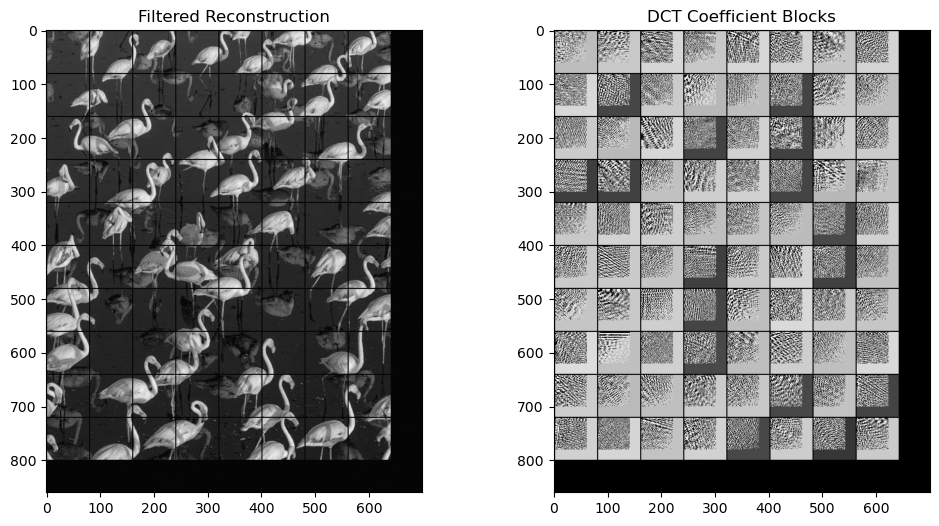

In [13]:
# Initialize the canvases
pixels_wow = np.zeros(gray.shape)
pixels_d = np.zeros(gray.shape)

# FIX: Use range() instead of xrange()
for y in range(height):
    for x in range(width):
        # FIX: Use floor division // to ensure the key matches your dictionary
        current_tile = (x // eight, y // eight)
        
        # Check if the tile exists (to avoid KeyErrors on image edges)
        if current_tile in dct_tiles:
            # Map the tile data back to the full-sized image
            pixels_d[y][x] = int(dct_tiles[current_tile][y % eight][x % eight])
            pixels_wow[y][x] = int(new_tiles[current_tile][y % eight][x % eight])
            
            # This creates a "grid" effect by zeroing out the borders of each tile
            if x % eight <= 1 or y % eight <= 1: 
                pixels_wow[y][x] = pixels_d[y][x] = 0

# Display the Reconstructed Image
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Filtered Reconstruction")
plt.imshow(pixels_wow, cmap='gray')

# Display the DCT Visualization
plt.subplot(1, 2, 2)
plt.title("DCT Coefficient Blocks")
plt.imshow(pixels_d, cmap='gray')
plt.show()